In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import statsmodels.api as sm
import matplotlib.pyplot as plt
import random
import os
import gc
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────
random.seed(42)
np.random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

# ============================================================
# FEATURE SETS
# ============================================================

VALUE    = ['bm','bm_ia','cfp','cfp_ia','ep','sp','dy']

QUALITY  = ['roaq','roeq','gma','operprof',
            'acc','absacc','pctacc',
            'tb','cashdebt','stdacc',
            'agr','egr','lgr','invest',
            'lev','ms','nincr']

MOMENTUM = ['mom1m','mom6m','mom12m','mom36m','chmom','indmom']

FEATURE_SETS = {
    'A_Value':           VALUE,
    'B_ValueQuality':    VALUE + QUALITY,
    'C_ValueQualityMom': VALUE + QUALITY + MOMENTUM,
    'D_ValMOM':          VALUE + MOMENTUM,
}

TARGET = 'ret'

# ── Per-model optimal settings ─────────────────────────────
COVERAGE = {
    'A_Value':           0.0,
    'B_ValueQuality':    0.5,
    'C_ValueQualityMom': 0.6,
    'D_ValMOM':          0.0,
}

TURNOVER_BUFFER = {
    'A_Value':           0,
    'B_ValueQuality':    2,
    'C_ValueQualityMom': 2,
    'D_ValMOM':          0,
}

# ── Cost constants ─────────────────────────────────────────
TC_ONEWAY            = 0.0050   # 50bps one-way transaction cost
BORROW_COST_ANNUAL   = 0.0150   # 150bps/yr stock borrow fee
REBATE_HAIRCUT       = 0.0025   # 25bps/yr prime broker haircut on RF rebate
CAPITAL_EFFICIENCY   = 1 / 1.5  # Reg T: need $1.50 capital per $1 L/S

# ── Train / OOS split ──────────────────────────────────────
TRAIN_END  = '2014-12-01'
TEST_START = '2015-01-01'
TEST_END   = '2021-12-01'
EXT_START  = '2022-01-01'
EXT_END    = '2024-11-01'

# ============================================================
# STEP 1: LOAD DATA
# ============================================================

print("Loading Kelly dataset...")
all_features = VALUE + QUALITY + MOMENTUM
load_cols    = ['permno','date',TARGET] + all_features

chunks = []
for chunk in pd.read_csv('kelly_final.csv',
                          usecols=lambda c: c in load_cols,
                          chunksize=500_000,
                          parse_dates=['date']):
    chunks.append(chunk)
kelly = pd.concat(chunks, ignore_index=True)
kelly = kelly.sort_values(['permno','date']).reset_index(drop=True)
del chunks
gc.collect()
print(f"Kelly: {len(kelly):,} rows  |  {kelly['date'].min()} → {kelly['date'].max()}")

print("\nLoading extension dataset...")
ext = pd.read_csv('features_2022_2024.csv', parse_dates=['date'])
ext = ext.sort_values(['permno','date']).reset_index(drop=True)
print(f"Extension: {len(ext):,} rows  |  {ext['date'].min()} → {ext['date'].max()}")

# ============================================================
# STEP 2: COVERAGE FILTER
# ============================================================

def apply_coverage_filter(df, feature_cols, min_coverage=0.0):
    if min_coverage <= 0:
        return df
    quality_cols = [c for c in feature_cols if c not in VALUE + MOMENTUM]
    if not quality_cols:
        return df
    coverage = df[quality_cols].notna().mean(axis=1)
    df_out   = df[coverage >= min_coverage].copy()
    pct      = 1 - len(df_out) / len(df)
    print(f"  Coverage >={min_coverage:.0%}: {len(df):,} → {len(df_out):,} ({pct:.1%} dropped)")
    return df_out

# ============================================================
# STEP 3: RANK NORMALISATION
# ============================================================

def rank_normalize(df, feature_cols):
    df = df.copy()

    def cs_rank(x):
        r = x.rank(method='average')
        if len(r) <= 1:
            return r * 0
        return (r - 1) / (len(r) - 1) * 2 - 1

    df[feature_cols] = df.groupby('date')[feature_cols].transform(
        lambda x: x.fillna(x.median())
    )
    df[feature_cols] = df[feature_cols].fillna(0)
    df[feature_cols] = df.groupby('date')[feature_cols].transform(cs_rank)
    return df


Loading Kelly dataset...
Kelly: 3,895,198 rows  |  1957-01-01 00:00:00 → 2021-12-01 00:00:00

Loading extension dataset...
Extension: 180,123 rows  |  2022-01-01 00:00:00 → 2024-11-01 00:00:00


In [2]:

# ============================================================
# STEP 4: FF5 FACTORS
# ============================================================

def get_ff5():
    import requests, zipfile, io
    url = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/"
           "ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip")
    print("Downloading FF5 factors...")
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    with z.open(z.namelist()[0]) as f:
        raw = f.read().decode('utf-8')
    lines = raw.split('\n')
    start = 0
    for i, line in enumerate(lines):
        s = line.strip()
        if s and s[0].isdigit() and len(s.split(',')[0].strip()) == 6:
            start = i
            break
    from io import StringIO
    ff5 = pd.read_csv(
        StringIO('\n'.join(lines[start:])),
        header=None,
        names=['date','MKT','SMB','HML','RMW','CMA','RF'],
        on_bad_lines='skip'
    )
    ff5 = ff5[ff5['date'].astype(str).str.strip().str.len() == 6]
    ff5['date'] = pd.to_datetime(ff5['date'].astype(str).str.strip(), format='%Y%m')
    ff5 = ff5.set_index('date')
    ff5 = ff5.apply(pd.to_numeric, errors='coerce') / 100
    ff5 = ff5.dropna()
    print(f"FF5: {ff5.index[0]} → {ff5.index[-1]}")
    return ff5

ff5       = get_ff5()
rf_series = ff5['RF']

# ============================================================
# STEP 5: PIOTROSKI F-SCORE (diagnostic only)
# ============================================================

def compute_fscore(month_df):
    df    = month_df.copy()
    score = pd.Series(0, index=df.index)
    for col in ['roaq','cfp','nincr']:
        if col in df.columns:
            score += (df[col] > 0).astype(int)
    if 'acc'      in df.columns: score += (df['acc']      < 0).astype(int)
    if 'lev'      in df.columns: score += (df['lev']      < 0).astype(int)
    if 'cashdebt' in df.columns: score += (df['cashdebt'] > 0).astype(int)
    if 'egr'      in df.columns: score += (df['egr']      < 0).astype(int)
    for col in ['gma','operprof']:
        if col in df.columns:
            score += (df[col] > 0).astype(int)
    return score


FF5: 1963-07-01 00:00:00 → 2026-02-01 00:00:00


In [3]:

# ============================================================
# STEP 6: PORTFOLIO BUILDER — FULL COST MODEL
# ============================================================

def build_portfolio_with_costs(month_df, n_deciles, date,
                                prev_long, prev_short,
                                tc               = TC_ONEWAY,
                                rf_rate          = 0.0,
                                borrow_cost_ann  = BORROW_COST_ANNUAL,
                                rebate_haircut   = REBATE_HAIRCUT,
                                cap_efficiency   = True,
                                turnover_buffer  = 0.0,
                                piotroski_filter = False,
                                piotroski_min    = 5,
                                piotroski_min_n  = 20):
    try:
        month_df = month_df.copy()
        month_df['decile'] = pd.qcut(
            month_df['pred'], n_deciles,
            labels=False, duplicates='drop'
        )
    except ValueError:
        return None

    actual_max = month_df['decile'].max()
    actual_min = month_df['decile'].min()
    if actual_max == actual_min or pd.isna(actual_max):
        return None

    long_df  = month_df[month_df['decile'] == actual_max].copy()
    short_df = month_df[month_df['decile'] == actual_min].copy()

    # Turnover buffer — carry incumbents still near top/bottom
    if turnover_buffer > 0 and len(prev_long) > 0:
        carry_long = month_df[
            (month_df['permno'].isin(prev_long)) &
            (month_df['decile'] >= actual_max - turnover_buffer)
        ]
        long_df = pd.concat([long_df, carry_long]).drop_duplicates('permno')
        carry_short = month_df[
            (month_df['permno'].isin(prev_short)) &
            (month_df['decile'] <= actual_min + turnover_buffer)
        ]
        short_df = pd.concat([short_df, carry_short]).drop_duplicates('permno')

    # F-score — always computed for diagnostics
    month_df['fscore'] = compute_fscore(month_df)
    long_df  = long_df.merge(month_df[['permno','fscore']], on='permno', how='left')
    short_df = short_df.merge(month_df[['permno','fscore']], on='permno', how='left')
    avg_fscore_long  = long_df['fscore'].mean()
    avg_fscore_short = short_df['fscore'].mean()

    # Piotroski hard filter (currently always False)
    if piotroski_filter:
        filtered = long_df[long_df['fscore'] >= piotroski_min]
        if len(filtered) >= piotroski_min_n:
            long_df = filtered

    if len(long_df) == 0:
        return None

    # ── Gross returns ──────────────────────────────────────────
    long_ret_gross  = long_df[TARGET].mean()
    short_ret_gross = short_df[TARGET].mean() if len(short_df) > 0 else 0.0

    curr_long  = set(long_df['permno'].values)
    curr_short = set(short_df['permno'].values)

    long_to  = len(curr_long  - prev_long)  / len(curr_long)  if prev_long  else 1.0
    short_to = len(curr_short - prev_short) / len(curr_short) if prev_short else 1.0

    # ── Cost rates (monthly) ───────────────────────────────────
    borrow_monthly  = borrow_cost_ann / 12
    haircut_monthly = rebate_haircut  / 12
    # Net short rebate: receive RF on short proceeds minus prime broker haircut
    # Floored at 0 — never negative (prime brokers keep all RF in near-zero environments)
    net_rebate = max(rf_rate - haircut_monthly, 0.0)

    # ── Net returns ────────────────────────────────────────────
    # Long book: pay TC on turnover
    long_ret_net = long_ret_gross - long_to * tc

    # Short book P&L:
    #   gain when shorted stocks fall  → -short_ret_gross
    #   receive short rebate           → +net_rebate
    #   pay borrow fee                 → -borrow_monthly
    #   pay TC on turnover             → -short_to * tc
    short_pnl = (-short_ret_gross
                 + net_rebate
                 - borrow_monthly
                 - short_to * tc)

    # Combined L/S before capital efficiency
    ls_ret_net_pre = long_ret_net + short_pnl

    # Capital efficiency: need $1.50 to run $1 L/S (Reg T 50% margin)
    ls_ret_net = ls_ret_net_pre * CAPITAL_EFFICIENCY if cap_efficiency \
                 else ls_ret_net_pre

    # Gross (zero cost reference)
    ls_ret_gross = long_ret_gross - short_ret_gross

    # Cost breakdown for transparency
    tc_cost     = (long_to + short_to) * tc
    net_fin     = net_rebate - borrow_monthly  # negative = net financing cost

    return {
        'date':                  date,
        'long_ret':              long_ret_net,
        'short_pnl':             short_pnl,
        'ls_ret':                ls_ret_net,
        'ls_ret_gross':          ls_ret_gross,
        'ls_ret_pre_capeff':     ls_ret_net_pre,
        'long_turnover':         long_to,
        'short_turnover':        short_to,
        'avg_turnover':          (long_to + short_to) / 2,
        'n_long':                len(long_df),
        'n_short':               len(short_df),
        'mkt_ret':               month_df[TARGET].mean(),
        'avg_fscore_long':       avg_fscore_long,
        'avg_fscore_short':      avg_fscore_short,
        'tc_cost_monthly':       tc_cost,
        'borrow_cost_monthly':   borrow_monthly,
        'rebate_monthly':        net_rebate,
        'net_financing_monthly': net_fin,
        'rf_rate':               rf_rate,
        'long_permnos':          curr_long,
        'short_permnos':         curr_short,
    }


In [4]:

# ============================================================
# STEP 7: TRAINING HELPERS
# ============================================================

def prepare_training_data(train_df, feature_cols, target_col='ret'):
    train       = train_df.dropna(subset=[target_col]).copy()
    X           = train[feature_cols].copy()
    y           = train[target_col].values
    col_medians = X.median()
    X           = X.fillna(col_medians).fillna(0).clip(-10, 10)
    X_vals      = X.values
    mask        = np.isfinite(X_vals).all(axis=1) & np.isfinite(y)
    return X_vals[mask], y[mask]

def predict_month(month_df, feature_cols, model):
    X = (month_df[feature_cols]
         .fillna(month_df[feature_cols].median())
         .fillna(0)
         .clip(-10, 10)
         .values)
    return model.predict(X)

def make_xgb(device):
    return XGBRegressor(
        n_estimators     = 500,
        learning_rate    = 0.01,
        max_depth        = 6,
        min_child_weight = 20,
        subsample        = 0.5,
        colsample_bytree = 0.5,
        reg_alpha        = 0.1,
        reg_lambda       = 0.1,
        random_state     = 42,
        seed             = 42,
        verbosity        = 0,
        device           = device,
        tree_method      = 'hist',
    )

# ============================================================
# STEP 8: GPU CHECK
# ============================================================

try:
    _t = XGBRegressor(device='cuda', n_estimators=10, verbosity=0)
    _t.fit([[1,2],[3,4]], [1,0])
    DEVICE = 'cuda'
    print("CUDA confirmed — using GPU")
except Exception:
    DEVICE = 'cpu'
    print("No CUDA — using CPU")


CUDA confirmed — using GPU


In [5]:

# ============================================================
# STEP 9: OOS BACKTEST ENGINE
# ============================================================

def run_backtest(kelly_df, ext_df, feature_cols, model_name,
                 train_end        = TRAIN_END,
                 test_start       = TEST_START,
                 test_end         = TEST_END,
                 ext_start        = EXT_START,
                 ext_end          = EXT_END,
                 n_deciles        = 10,
                 transaction_cost = TC_ONEWAY,
                 min_coverage     = 0.0,
                 turnover_buffer  = 0.0,
                 piotroski_filter = False):

    print(f"\n{'='*60}")
    print(f"OOS — {model_name} | {len(feature_cols)} features")
    print(f"Coverage: {min_coverage:.0%} | Buffer: {turnover_buffer}")
    print(f"Train: 1957–{train_end} | OOS: {test_start}–{test_end} | Ext: {ext_start}–{ext_end}")
    print(f"{'='*60}")

    kelly_f    = apply_coverage_filter(kelly_df, feature_cols, min_coverage)
    ext_f      = apply_coverage_filter(ext_df,   feature_cols, min_coverage)
    kelly_proc = rank_normalize(kelly_f, feature_cols)
    ext_proc   = rank_normalize(ext_f,   feature_cols)

    test_dates = sorted(kelly_proc[
        (kelly_proc['date'] >= test_start) &
        (kelly_proc['date'] <= test_end)
    ]['date'].unique())

    ext_dates = sorted(ext_proc[
        (ext_proc['date'] >= ext_start) &
        (ext_proc['date'] <= ext_end)
    ]['date'].unique())

    results           = []
    model             = None
    last_retrain_year = None
    prev_long         = set()
    prev_short        = set()

    # Pre-train on all data up to and including train_end
    print(f"\nPre-training on data ≤ {train_end}...")
    pretrain     = kelly_proc[kelly_proc['date'] <= train_end]
    X_pre, y_pre = prepare_training_data(pretrain, feature_cols)
    if len(y_pre) < 1000:
        raise ValueError(f"Only {len(y_pre)} obs in pre-train — check dates")
    model = make_xgb(DEVICE)
    model.fit(X_pre, y_pre)
    last_retrain_year = pd.Timestamp(test_start).year - 1
    print(f"  Pre-trained on {len(y_pre):,} obs")

    # OOS loop
    print(f"Running OOS ({len(test_dates)} months)...")
    for test_date in test_dates:
        current_year = test_date.year

        if current_year != last_retrain_year:
            train      = kelly_proc[kelly_proc['date'] < test_date]
            X_tr, y_tr = prepare_training_data(train, feature_cols)
            if len(y_tr) >= 1000:
                new_model = make_xgb(DEVICE)
                new_model.fit(X_tr, y_tr)
                model             = new_model
                last_retrain_year = current_year
                print(f"  [{test_date.strftime('%Y-%m')}] Retrained on {len(y_tr):,} obs")
            else:
                print(f"  [{test_date.strftime('%Y-%m')}] WARNING: {len(y_tr):,} obs — keeping prev")

        month_df = kelly_proc[kelly_proc['date'] == test_date].copy()
        if len(month_df) < 20:
            continue
        month_df['pred'] = predict_month(month_df, feature_cols, model)
        monthly_rf       = rf_series.get(test_date, 0.0)

        result = build_portfolio_with_costs(
            month_df, n_deciles, test_date, prev_long, prev_short,
            tc              = transaction_cost,
            rf_rate         = monthly_rf,
            borrow_cost_ann = BORROW_COST_ANNUAL,
            rebate_haircut  = REBATE_HAIRCUT,
            cap_efficiency  = True,
            turnover_buffer = turnover_buffer,
            piotroski_filter= piotroski_filter,
        )
        if result:
            prev_long  = result.pop('long_permnos')
            prev_short = result.pop('short_permnos')
            results.append(result)

    # Extension
    print(f"Running extension ({len(ext_dates)} months)...")
    X_full, y_full = prepare_training_data(kelly_proc, feature_cols)
    model_full = make_xgb(DEVICE)
    model_full.fit(X_full, y_full)
    print(f"  Full model trained on {len(y_full):,} obs")

    prev_long  = set()
    prev_short = set()
    for ext_date in ext_dates:
        month_df = ext_proc[ext_proc['date'] == ext_date].copy()
        if len(month_df) < 20:
            continue
        month_df['pred'] = predict_month(month_df, feature_cols, model_full)
        monthly_rf       = rf_series.get(ext_date, 0.0)

        result = build_portfolio_with_costs(
            month_df, n_deciles, ext_date, prev_long, prev_short,
            tc              = transaction_cost,
            rf_rate         = monthly_rf,
            borrow_cost_ann = BORROW_COST_ANNUAL,
            rebate_haircut  = REBATE_HAIRCUT,
            cap_efficiency  = True,
            turnover_buffer = turnover_buffer,
            piotroski_filter= piotroski_filter,
        )
        if result:
            prev_long  = result.pop('long_permnos')
            prev_short = result.pop('short_permnos')
            results.append(result)

    port = pd.DataFrame(results).set_index('date')
    expected = pd.date_range(port.index.min(), port.index.max(), freq='MS')
    missing  = expected.difference(port.index)
    print(f"\n  Months: {len(port)} | Missing: {len(missing)} | "
          f"Avg TO: {port['avg_turnover'].mean():.1%}")
    return port, model_full


In [6]:

# ============================================================
# STEP 10: IN-SAMPLE BACKTEST ENGINE
# Covers 1962-2014 (need 5yr min data before first retrain)
# Uses expanding window retrains — same logic as OOS
# IMPORTANT: these are in-sample, model has seen this data
# Use only for overfitting diagnostics, not allocation
# ============================================================

def run_insample(kelly_df, feature_cols, model_name,
                 is_start         = '1962-01-01',
                 train_end        = TRAIN_END,
                 n_deciles        = 10,
                 transaction_cost = TC_ONEWAY,
                 min_coverage     = 0.0,
                 turnover_buffer  = 0.0):

    print(f"\n{'='*60}")
    print(f"IN-SAMPLE — {model_name} | {len(feature_cols)} features")
    print(f"Period: {is_start} → {train_end}")
    print(f"{'='*60}")

    kelly_f    = apply_coverage_filter(kelly_df, feature_cols, min_coverage)
    kelly_proc = rank_normalize(kelly_f, feature_cols)

    is_dates = sorted(kelly_proc[
        (kelly_proc['date'] >= is_start) &
        (kelly_proc['date'] <= train_end)
    ]['date'].unique())

    results           = []
    model             = None
    last_retrain_year = None
    prev_long         = set()
    prev_short        = set()

    print(f"Running {len(is_dates)} in-sample months...")

    for test_date in is_dates:
        current_year = test_date.year

        if current_year != last_retrain_year:
            train      = kelly_proc[kelly_proc['date'] < test_date]
            X_tr, y_tr = prepare_training_data(train, feature_cols)

            if len(y_tr) < 500:
                last_retrain_year = current_year
                continue

            new_model = make_xgb(DEVICE)
            new_model.fit(X_tr, y_tr)
            model             = new_model
            last_retrain_year = current_year

            if current_year % 5 == 0:
                print(f"  [{test_date.strftime('%Y-%m')}] Retrained on {len(y_tr):,} obs")

        if model is None:
            continue

        month_df = kelly_proc[kelly_proc['date'] == test_date].copy()
        if len(month_df) < 20:
            continue

        month_df['pred'] = predict_month(month_df, feature_cols, model)
        monthly_rf       = rf_series.get(test_date, 0.0)

        result = build_portfolio_with_costs(
            month_df, n_deciles, test_date, prev_long, prev_short,
            tc              = transaction_cost,
            rf_rate         = monthly_rf,
            borrow_cost_ann = BORROW_COST_ANNUAL,
            rebate_haircut  = REBATE_HAIRCUT,
            cap_efficiency  = True,
            turnover_buffer = turnover_buffer,
            piotroski_filter= False,
        )
        if result:
            prev_long  = result.pop('long_permnos')
            prev_short = result.pop('short_permnos')
            results.append(result)

    port = pd.DataFrame(results).set_index('date')
    print(f"  Done: {len(port)} months")
    return port

# ============================================================
# STEP 11: FF5 LINEAR BENCHMARK
# ============================================================

def run_ff5_benchmark(kelly_df, ext_df,
                      test_start=TEST_START, test_end=TEST_END,
                      ext_start=EXT_START,   ext_end=EXT_END,
                      rolling_window=60, n_deciles=10,
                      transaction_cost=TC_ONEWAY):

    print("\n" + "="*60)
    print("FF5 Linear Benchmark (Vectorized + CuPy GPU)")
    print(f"Window: {rolling_window}m | TC: {transaction_cost*10000:.0f}bps")
    print("="*60)

    try:
        import cupy as cp
        from cupy.linalg import inv as cp_inv
        USE_GPU = True
        _ = cp.array([1.0])
        cp.cuda.Stream.null.synchronize()
        print("CuPy — GPU")
    except ImportError:
        USE_GPU = False
        cp = np
        cp_inv = np.linalg.inv
        print("NumPy — CPU")

    all_rets   = pd.concat([kelly_df[['permno','date','ret']],
                             ext_df[['permno','date','ret']]], ignore_index=True)
    ret_matrix = all_rets.pivot(index='date', columns='permno', values='ret').sort_index()
    print(f"Return matrix: {ret_matrix.shape}")

    factors  = ff5[['MKT','SMB','HML','RMW','CMA']].reindex(ret_matrix.index)
    ret_vals = ret_matrix.values.astype(np.float32)
    fac_vals = factors.values.astype(np.float32)

    if USE_GPU:
        ret_gpu = cp.array(ret_vals)
        fac_gpu = cp.array(fac_vals)
        ones_w  = cp.ones((rolling_window, 1), dtype=cp.float32)
    else:
        ret_gpu = ret_vals
        fac_gpu = fac_vals
        ones_w  = np.ones((rolling_window, 1), dtype=np.float32)

    permnos    = ret_matrix.columns.values
    date_index = ret_matrix.index
    all_dates  = [d for d in pd.date_range(test_start, ext_end, freq='MS')
                  if d in date_index]

    results    = []
    prev_long  = set()
    prev_short = set()

    print(f"Processing {len(all_dates)} months...")
    for t_idx, test_date in enumerate(all_dates):
        if t_idx % 12 == 0:
            print(f"  [{test_date.strftime('%Y-%m')}]")

        date_pos = date_index.get_loc(test_date)
        if date_pos < rolling_window:
            continue

        w  = slice(date_pos - rolling_window, date_pos)
        F  = fac_gpu[w]
        R  = ret_gpu[w]
        X  = cp.hstack([ones_w, F]) if USE_GPU else np.hstack([ones_w, F])

        try:
            XtX     = X.T @ X
            XtX_inv = cp_inv(XtX)
            B       = XtX_inv @ (X.T @ R)
        except Exception:
            continue

        curr_f = fac_vals[date_pos]
        curr_X = np.array([1.0, *curr_f], dtype=np.float32)

        if USE_GPU:
            pred_np      = cp.asnumpy(cp.array(curr_X) @ B)
            nan_count    = cp.isnan(R).sum(axis=0)
            curr_rets_np = cp.asnumpy(ret_gpu[date_pos])
            valid_np     = cp.asnumpy(
                ((rolling_window - nan_count) >= 24) &
                ~cp.isnan(ret_gpu[date_pos])
            )
        else:
            pred_np      = curr_X @ B
            nan_count    = np.isnan(R).sum(axis=0)
            curr_rets_np = ret_vals[date_pos]
            valid_np     = ((rolling_window - nan_count) >= 24) & ~np.isnan(curr_rets_np)

        valid_idx = np.where(valid_np)[0]
        if len(valid_idx) < 50:
            continue

        pred_df = pd.DataFrame({
            'permno': permnos[valid_idx],
            'pred':   pred_np[valid_idx],
            'ret':    curr_rets_np[valid_idx],
        })

        try:
            pred_df['decile'] = pd.qcut(pred_df['pred'], n_deciles,
                                         labels=False, duplicates='drop')
        except ValueError:
            continue

        actual_max = pred_df['decile'].max()
        actual_min = pred_df['decile'].min()
        if actual_max == actual_min:
            continue

        long_df  = pred_df[pred_df['decile'] == actual_max]
        short_df = pred_df[pred_df['decile'] == actual_min]
        if len(long_df) == 0:
            continue

        long_gross  = long_df['ret'].mean()
        short_gross = short_df['ret'].mean() if len(short_df) > 0 else 0.0

        curr_long  = set(long_df['permno'].values)
        curr_short = set(short_df['permno'].values)
        long_to    = len(curr_long  - prev_long)  / len(curr_long)  if prev_long  else 1.0
        short_to   = len(curr_short - prev_short) / len(curr_short) if prev_short else 1.0

        monthly_rf  = rf_series.get(test_date, 0.0)
        net_rebate  = max(monthly_rf - REBATE_HAIRCUT/12, 0.0)
        short_pnl   = (-short_gross + net_rebate
                       - BORROW_COST_ANNUAL/12 - short_to * transaction_cost)
        long_net    = long_gross - long_to * transaction_cost
        ls_net_pre  = long_net + short_pnl
        ls_net      = ls_net_pre * CAPITAL_EFFICIENCY

        results.append({
            'date':                  test_date,
            'long_ret':              long_net,
            'short_pnl':             short_pnl,
            'ls_ret':                ls_net,
            'ls_ret_gross':          long_gross - short_gross,
            'ls_ret_pre_capeff':     ls_net_pre,
            'long_turnover':         long_to,
            'short_turnover':        short_to,
            'avg_turnover':          (long_to + short_to) / 2,
            'n_long':                len(long_df),
            'n_short':               len(short_df),
            'mkt_ret':               pred_df['ret'].mean(),
            'avg_fscore_long':       np.nan,
            'avg_fscore_short':      np.nan,
            'tc_cost_monthly':       (long_to + short_to) * transaction_cost,
            'borrow_cost_monthly':   BORROW_COST_ANNUAL / 12,
            'rebate_monthly':        net_rebate,
            'net_financing_monthly': net_rebate - BORROW_COST_ANNUAL/12,
            'rf_rate':               monthly_rf,
        })
        prev_long  = curr_long
        prev_short = curr_short

    if USE_GPU:
        del ret_gpu, fac_gpu, ones_w
        cp.get_default_memory_pool().free_all_blocks()

    port = pd.DataFrame(results).set_index('date')
    print(f"Done: {len(port)} months | avg TO: {port['avg_turnover'].mean():.1%}")
    return port

# ============================================================
# STEP 12: ROLLING METRIC HELPERS
# ============================================================

def rolling_cumret(s, w):
    return s.rolling(w, min_periods=w//2).apply(
        lambda x: (1+x).prod()-1, raw=False)

def rolling_sharpe(s, rf, w):
    ex = s - rf.reindex(s.index).fillna(0)
    return (ex.rolling(w, min_periods=w//2).mean() /
            ex.rolling(w, min_periods=w//2).std() * np.sqrt(12))

def rolling_sortino(s, rf, w):
    ex  = s - rf.reindex(s.index).fillna(0)
    dn  = ex.clip(upper=0).rolling(w, min_periods=w//2).std()
    return (ex.rolling(w, min_periods=w//2).mean() / dn * np.sqrt(12))

def rolling_maxdd(s, w):
    def _mdd(x):
        c = (1+x).cumprod()
        return ((c - c.cummax()) / c.cummax()).min()
    return s.rolling(w, min_periods=w//2).apply(_mdd, raw=False)

def rolling_calmar(s, w):
    ann = s.rolling(w, min_periods=w//2).apply(
        lambda x: (1+x).prod()**(12/len(x))-1, raw=False)
    mdd = rolling_maxdd(s, w).abs()
    return ann / mdd.replace(0, np.nan)

def rolling_hitrate(s, w):
    return (s > 0).rolling(w, min_periods=w//2).mean()


In [7]:

# ============================================================
# STEP 13: MASTER CSV BUILDER
# ============================================================

def build_allocation_csv(port_dict, rf_series, hml, period='oos'):
    """
    Builds the master allocation CSV.
    period: 'oos' or 'in_sample' — written into the 'period' column.
    For OOS: includes HML_Passive row.
    For in-sample: ML strategies only.
    """
    all_rows = []
    strats   = dict(port_dict)

    # Add HML Passive for OOS only
    if period == 'oos':
        hml_full = hml.reindex(
            pd.date_range('2015-01-01', '2024-11-01', freq='MS')
        ).dropna()
        hml_df = pd.DataFrame({
            'ls_ret':                hml_full,
            'ls_ret_gross':          hml_full,
            'ls_ret_pre_capeff':     hml_full,
            'long_ret':              hml_full,
            'short_pnl':             pd.Series(0.0, index=hml_full.index),
            'long_turnover':         np.nan,
            'short_turnover':        np.nan,
            'avg_turnover':          np.nan,
            'n_long':                np.nan,
            'n_short':               np.nan,
            'mkt_ret':               np.nan,
            'avg_fscore_long':       np.nan,
            'avg_fscore_short':      np.nan,
            'tc_cost_monthly':       np.nan,
            'borrow_cost_monthly':   np.nan,
            'rebate_monthly':        np.nan,
            'net_financing_monthly': np.nan,
            'rf_rate':               rf_series.reindex(hml_full.index).fillna(0),
        })
        strats['HML_Passive'] = hml_df

    for strat_name, port in strats.items():
        print(f"  Rolling metrics: {strat_name} ({period})...")
        rets = port['ls_ret'].copy()

        nav         = (1 + rets).cumprod()
        ret_1m      = rets
        ret_3m      = rolling_cumret(rets, 3)
        ret_6m      = rolling_cumret(rets, 6)
        ret_12m     = rolling_cumret(rets, 12)
        ret_24m     = rolling_cumret(rets, 24)
        ret_36m     = rolling_cumret(rets, 36)
        vol_12m     = rets.rolling(12, min_periods=6).std()  * np.sqrt(12)
        vol_36m     = rets.rolling(36, min_periods=18).std() * np.sqrt(12)
        mdd_6m      = rolling_maxdd(rets, 6)
        mdd_12m     = rolling_maxdd(rets, 12)
        mdd_36m     = rolling_maxdd(rets, 36)
        sharpe_12m  = rolling_sharpe(rets, rf_series, 12)
        sharpe_36m  = rolling_sharpe(rets, rf_series, 36)
        sortino_12m = rolling_sortino(rets, rf_series, 12)
        sortino_36m = rolling_sortino(rets, rf_series, 36)
        calmar_12m  = rolling_calmar(rets, 12)
        calmar_36m  = rolling_calmar(rets, 36)
        hit_3m      = rolling_hitrate(rets, 3)
        hit_6m      = rolling_hitrate(rets, 6)
        hit_12m     = rolling_hitrate(rets, 12)

        def g(series, date):
            try:   return series.loc[date]
            except: return np.nan

        def gc(col, date):
            if col not in port.columns: return np.nan
            try:   return port[col].loc[date]
            except: return np.nan

        for date in rets.index:
            all_rows.append({
                'date':     date,
                'strategy': strat_name,
                'period':   period,

                # Raw returns
                'ls_ret':            g(rets, date),
                'ls_ret_gross':      gc('ls_ret_gross', date),
                'ls_ret_pre_capeff': gc('ls_ret_pre_capeff', date),
                'long_ret':          gc('long_ret', date),
                'short_pnl':         gc('short_pnl', date),

                # Turnover & sizing
                'long_turnover':     gc('long_turnover', date),
                'short_turnover':    gc('short_turnover', date),
                'avg_turnover':      gc('avg_turnover', date),
                'n_long':            gc('n_long', date),
                'n_short':           gc('n_short', date),
                'mkt_ret':           gc('mkt_ret', date),

                # Cost breakdown
                'tc_cost_monthly':       gc('tc_cost_monthly', date),
                'borrow_cost_monthly':   gc('borrow_cost_monthly', date),
                'rebate_monthly':        gc('rebate_monthly', date),
                'net_financing_monthly': gc('net_financing_monthly', date),
                'rf_rate':               gc('rf_rate', date),

                # Quality diagnostics
                'avg_fscore_long':   gc('avg_fscore_long', date),
                'avg_fscore_short':  gc('avg_fscore_short', date),

                # NAV
                'nav': g(nav, date),

                # Rolling cumulative returns
                'ret_1m':  g(ret_1m,  date),
                'ret_3m':  g(ret_3m,  date),
                'ret_6m':  g(ret_6m,  date),
                'ret_12m': g(ret_12m, date),
                'ret_24m': g(ret_24m, date),
                'ret_36m': g(ret_36m, date),

                # Rolling vol
                'vol_12m': g(vol_12m, date),
                'vol_36m': g(vol_36m, date),

                # Rolling drawdown
                'max_dd_6m':  g(mdd_6m,  date),
                'max_dd_12m': g(mdd_12m, date),
                'max_dd_36m': g(mdd_36m, date),

                # Rolling Sharpe (RF-adjusted)
                'sharpe_12m':  g(sharpe_12m,  date),
                'sharpe_36m':  g(sharpe_36m,  date),

                # Rolling Sortino
                'sortino_12m': g(sortino_12m, date),
                'sortino_36m': g(sortino_36m, date),

                # Rolling Calmar
                'calmar_12m':  g(calmar_12m, date),
                'calmar_36m':  g(calmar_36m, date),

                # Hit rate
                'hit_rate_3m':  g(hit_3m,  date),
                'hit_rate_6m':  g(hit_6m,  date),
                'hit_rate_12m': g(hit_12m, date),
            })

    df = pd.DataFrame(all_rows)
    df = df.sort_values(['strategy','date']).reset_index(drop=True)
    df['date'] = pd.to_datetime(df['date'])
    fc = df.select_dtypes(include=[np.floating]).columns
    df[fc] = df[fc].round(6)
    return df


In [8]:

# ============================================================
# STEP 14: PERFORMANCE REPORTING HELPERS
# ============================================================

def compute_metrics(returns, name='Strategy', rf=None):
    returns   = returns.dropna()
    rf_a      = rf.reindex(returns.index).fillna(0) if rf is not None \
                else pd.Series(0, index=returns.index)
    excess    = returns - rf_a
    ann_ret   = (1+returns).prod() ** (12/len(returns)) - 1
    ann_vol   = returns.std() * np.sqrt(12)
    sharpe    = excess.mean() / excess.std() * np.sqrt(12)
    cum       = (1+returns).cumprod()
    max_dd    = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar    = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    hit_rate  = (returns > 0).mean()
    return {
        'Name':       name,
        'Ann Return': f"{ann_ret:.2%}",
        'Ann Vol':    f"{ann_vol:.2%}",
        'Sharpe':     f"{sharpe:.2f}",
        'Max DD':     f"{max_dd:.2%}",
        'Calmar':     f"{calmar:.2f}",
        'Hit Rate':   f"{hit_rate:.1%}",
    }

def compute_yearly_metrics(returns, name='Strategy', rf=None):
    returns  = returns.dropna()
    rf_a     = rf.reindex(returns.index).fillna(0) if rf is not None \
               else pd.Series(0, index=returns.index)
    rows = []
    for year in sorted(returns.index.year.unique()):
        yr  = returns[returns.index.year == year]
        yrf = rf_a[rf_a.index.year == year]
        if len(yr) < 3: continue
        ex  = yr - yrf
        rows.append({
            'Year':       year,
            'Name':       name,
            'Ann Return': (1+yr).prod() - 1,
            'Sharpe':     ex.mean()/ex.std()*np.sqrt(12) if ex.std()>0 else np.nan,
            'Max DD':     ((( 1+yr).cumprod() / (1+yr).cumprod().cummax()) - 1).min(),
        })
    return pd.DataFrame(rows)


In [9]:

# ============================================================
# STEP 15: RUN OOS BACKTESTS
# ============================================================

portfolios   = {}
final_models = {}

for model_name, feature_cols in FEATURE_SETS.items():
    port, model = run_backtest(
        kelly, ext, feature_cols, model_name,
        min_coverage     = COVERAGE[model_name],
        turnover_buffer  = TURNOVER_BUFFER[model_name],
        piotroski_filter = False,
    )
    portfolios[model_name]   = port
    final_models[model_name] = model
    gc.collect()

# FF5 linear benchmark
ff5_port = run_ff5_benchmark(kelly, ext)
portfolios['FF5_Linear'] = ff5_port

print("\nAll OOS models complete.")



OOS — A_Value | 7 features
Coverage: 0% | Buffer: 0
Train: 1957–2014-12-01 | OOS: 2015-01-01–2021-12-01 | Ext: 2022-01-01–2024-11-01

Pre-training on data ≤ 2014-12-01...
  Pre-trained on 3,420,436 obs
Running OOS (84 months)...
  [2015-01] Retrained on 3,420,436 obs
  [2016-01] Retrained on 3,486,964 obs
  [2017-01] Retrained on 3,552,691 obs
  [2018-01] Retrained on 3,618,849 obs
  [2019-01] Retrained on 3,685,516 obs
  [2020-01] Retrained on 3,751,509 obs
  [2021-01] Retrained on 3,818,256 obs
Running extension (35 months)...
  Full model trained on 3,895,198 obs

  Months: 119 | Missing: 0 | Avg TO: 27.5%

OOS — B_ValueQuality | 24 features
Coverage: 50% | Buffer: 2
Train: 1957–2014-12-01 | OOS: 2015-01-01–2021-12-01 | Ext: 2022-01-01–2024-11-01
  Coverage >=50%: 3,895,198 → 2,616,786 (32.8% dropped)
  Coverage >=50%: 180,123 → 159,729 (11.3% dropped)

Pre-training on data ≤ 2014-12-01...
  Pre-trained on 2,278,970 obs
Running OOS (84 months)...
  [2015-01] Retrained on 2,278,970 

In [10]:

# ============================================================
# STEP 16: RUN IN-SAMPLE BACKTESTS
# Only A, B, C (not D, not FF5)
# ============================================================

IS_MODELS  = ['A_Value', 'B_ValueQuality', 'C_ValueQualityMom']
is_portfolios = {}

for model_name in IS_MODELS:
    feature_cols = FEATURE_SETS[model_name]
    port_is = run_insample(
        kelly, feature_cols, model_name,
        train_end       = TRAIN_END,
        min_coverage    = COVERAGE[model_name],
        turnover_buffer = TURNOVER_BUFFER[model_name],
    )
    is_portfolios[model_name] = port_is
    gc.collect()

print("\nAll in-sample models complete.")



IN-SAMPLE — A_Value | 7 features
Period: 1962-01-01 → 2014-12-01
Running 636 in-sample months...
  [1965-01] Retrained on 131,805 obs
  [1970-01] Retrained on 261,658 obs
  [1975-01] Retrained on 474,016 obs
  [1980-01] Retrained on 758,573 obs
  [1985-01] Retrained on 1,061,459 obs
  [1990-01] Retrained on 1,417,683 obs
  [1995-01] Retrained on 1,802,770 obs
  [2000-01] Retrained on 2,302,314 obs
  [2005-01] Retrained on 2,718,235 obs
  [2010-01] Retrained on 3,094,529 obs
  Done: 636 months

IN-SAMPLE — B_ValueQuality | 24 features
Period: 1962-01-01 → 2014-12-01
  Coverage >=50%: 3,895,198 → 2,616,786 (32.8% dropped)
Running 618 in-sample months...
  [1965-01] Retrained on 796 obs
  [1970-01] Retrained on 33,446 obs
  [1975-01] Retrained on 148,314 obs
  [1980-01] Retrained on 346,024 obs
  [1985-01] Retrained on 555,526 obs
  [1990-01] Retrained on 791,607 obs
  [1995-01] Retrained on 1,049,390 obs
  [2000-01] Retrained on 1,405,320 obs
  [2005-01] Retrained on 1,736,094 obs
  [20

In [11]:

# ============================================================
# STEP 17: BUILD AND SAVE CSVs
# ============================================================

hml = ff5['HML']

print("\nBuilding OOS master CSV...")
master_oos = build_allocation_csv(portfolios, rf_series, hml, period='oos')
master_oos.to_csv('master_allocation.csv', index=False)
print(f"Saved: master_allocation.csv  "
      f"({master_oos.shape[0]:,} rows × {master_oos.shape[1]} cols)")

print("\nBuilding in-sample CSV...")
master_is = build_allocation_csv(is_portfolios, rf_series, hml, period='in_sample')
master_is.to_csv('insample_allocation.csv', index=False)
print(f"Saved: insample_allocation.csv  "
      f"({master_is.shape[0]:,} rows × {master_is.shape[1]} cols)")

print("\nBuilding combined full history CSV...")
common_cols   = [c for c in master_oos.columns if c in master_is.columns]
full_history  = pd.concat(
    [master_oos[common_cols], master_is[common_cols]],
    ignore_index=True
)
full_history  = full_history.sort_values(['strategy','date']).reset_index(drop=True)
full_history.to_csv('full_history_allocation.csv', index=False)
print(f"Saved: full_history_allocation.csv  "
      f"({full_history.shape[0]:,} rows × {full_history.shape[1]} cols)")
print(f"  Date range: {full_history['date'].min()} → {full_history['date'].max()}")
print(f"  Strategies: {sorted(full_history['strategy'].unique())}")



Building OOS master CSV...
  Rolling metrics: A_Value (oos)...
  Rolling metrics: B_ValueQuality (oos)...
  Rolling metrics: C_ValueQualityMom (oos)...
  Rolling metrics: D_ValMOM (oos)...
  Rolling metrics: FF5_Linear (oos)...
  Rolling metrics: HML_Passive (oos)...
Saved: master_allocation.csv  (714 rows × 42 cols)

Building in-sample CSV...
  Rolling metrics: A_Value (in_sample)...
  Rolling metrics: B_ValueQuality (in_sample)...
  Rolling metrics: C_ValueQualityMom (in_sample)...
Saved: insample_allocation.csv  (1,824 rows × 42 cols)

Building combined full history CSV...
Saved: full_history_allocation.csv  (2,538 rows × 42 cols)
  Date range: 1962-01-01 00:00:00 → 2024-11-01 00:00:00
  Strategies: ['A_Value', 'B_ValueQuality', 'C_ValueQualityMom', 'D_ValMOM', 'FF5_Linear', 'HML_Passive']


In [12]:

# ============================================================
# STEP 18: PERFORMANCE SUMMARY
# ============================================================

print("\n" + "="*70)
print("PERFORMANCE SUMMARY — OOS (net, full cost model)")
print("="*70)
rows = []
for name, port in portfolios.items():
    rows.append(compute_metrics(port['ls_ret'], name=f"{name}_net", rf=rf_series))
    if 'ls_ret_gross' in port.columns:
        rows.append(compute_metrics(port['ls_ret_gross'], name=f"{name}_gross", rf=rf_series))
hml_oos = hml.reindex(portfolios['A_Value'].index).dropna()
rows.append(compute_metrics(hml_oos, name='HML_Passive', rf=rf_series))
print(pd.DataFrame(rows).set_index('Name').to_string())

print("\nTurnover & Cost breakdown:")
print(f"{'Model':<25} {'Avg TO':>8} {'TC/yr':>8} {'Borrow/yr':>10} "
      f"{'Rebate/yr':>10} {'Net fin/yr':>12}")
print("-"*75)
for name, port in portfolios.items():
    if 'avg_turnover' not in port.columns: continue
    avg_to   = port['avg_turnover'].mean()
    tc_yr    = port['tc_cost_monthly'].mean()    * 12 * 100 if 'tc_cost_monthly'    in port.columns else 0
    bor_yr   = port['borrow_cost_monthly'].mean()* 12 * 100 if 'borrow_cost_monthly' in port.columns else 0
    reb_yr   = port['rebate_monthly'].mean()     * 12 * 100 if 'rebate_monthly'      in port.columns else 0
    fin_yr   = port['net_financing_monthly'].mean()*12*100  if 'net_financing_monthly' in port.columns else 0
    print(f"{name:<25} {avg_to:>7.1%} {tc_yr:>7.2f}% {bor_yr:>9.2f}% "
          f"{reb_yr:>9.2f}% {fin_yr:>11.2f}%")



PERFORMANCE SUMMARY — OOS (net, full cost model)
                        Ann Return Ann Vol Sharpe   Max DD Calmar Hit Rate
Name                                                                      
A_Value_net                 10.70%  10.62%   0.86  -13.72%   0.78    60.5%
A_Value_gross               19.85%  15.81%   1.13  -19.00%   1.04    63.0%
B_ValueQuality_net           8.53%   9.26%   0.76  -22.52%   0.38    59.7%
B_ValueQuality_gross        17.97%  13.73%   1.16  -27.00%   0.67    65.5%
C_ValueQualityMom_net       11.71%  11.98%   0.85  -26.67%   0.44    64.7%
C_ValueQualityMom_gross     23.18%  17.76%   1.18  -33.59%   0.69    65.5%
D_ValMOM_net                18.23%  12.77%   1.26  -12.57%   1.45    65.5%
D_ValMOM_gross              34.16%  19.10%   1.57  -16.39%   2.08    67.2%
FF5_Linear_net              -6.36%   6.92%  -1.15  -48.43%  -0.13    37.0%
FF5_Linear_gross            -0.81%  10.40%  -0.18  -27.83%  -0.03    49.6%
HML_Passive                 -2.74%  13.14%  -0.27 

In [13]:

# ============================================================
# STEP 19: REGIME & YEARLY ANALYSIS
# ============================================================

regimes = {
    'Full OOS (2015-2024)':   (TEST_START, '2024-11-01'),
    'Lost Decade (2015-2020)':('2015-01-01','2020-12-01'),
    'Post-COVID (2020-2022)': ('2020-01-01','2022-12-01'),
    'Extension (2022-2024)':  (EXT_START,   EXT_END),
}

print("\n" + "="*70)
print("REGIME ANALYSIS")
print("="*70)
regime_rows = []
for regime, (s, e) in regimes.items():
    for name, port in portfolios.items():
        rets = port['ls_ret'][s:e].dropna()
        if len(rets) < 3: continue
        m = compute_metrics(rets, name=name, rf=rf_series)
        m['Regime'] = regime
        regime_rows.append(m)
    hml_r = hml[s:e].dropna()
    if len(hml_r) >= 3:
        m = compute_metrics(hml_r, name='HML_Passive', rf=rf_series)
        m['Regime'] = regime
        regime_rows.append(m)
regime_df = (pd.DataFrame(regime_rows)
             .set_index(['Regime','Name'])
             [['Ann Return','Sharpe','Max DD']])
print(regime_df.to_string())

print("\n" + "="*70)
print("YEARLY METRICS")
print("="*70)
all_yr = []
for name, port in portfolios.items():
    all_yr.append(compute_yearly_metrics(port['ls_ret'], name=name, rf=rf_series))
hml_full = hml.reindex(pd.date_range('2015-01-01','2024-11-01',freq='MS')).dropna()
all_yr.append(compute_yearly_metrics(hml_full, name='HML_Passive', rf=rf_series))
yearly_df     = pd.concat(all_yr, ignore_index=True)
yearly_return = yearly_df.pivot(index='Year', columns='Name', values='Ann Return')
yearly_sharpe = yearly_df.pivot(index='Year', columns='Name', values='Sharpe')
print("\nYearly Returns:")
print(yearly_return.applymap(lambda x: f"{x:.1%}" if pd.notna(x) else "—").to_string())
print("\nYearly Sharpe:")
print(yearly_sharpe.applymap(lambda x: f"{x:.2f}" if pd.notna(x) else "—").to_string())
yearly_return.to_csv('yearly_returns.csv')
yearly_sharpe.to_csv('yearly_sharpe.csv')



REGIME ANALYSIS
                                          Ann Return Sharpe   Max DD
Regime                  Name                                        
Full OOS (2015-2024)    A_Value               10.70%   0.86  -13.72%
                        B_ValueQuality         8.53%   0.76  -22.52%
                        C_ValueQualityMom     11.71%   0.85  -26.67%
                        D_ValMOM              18.23%   1.26  -12.57%
                        FF5_Linear            -6.36%  -1.15  -48.43%
                        HML_Passive           -2.74%  -0.27  -51.32%
Lost Decade (2015-2020) A_Value                4.27%   0.39  -13.72%
                        B_ValueQuality         0.38%  -0.02  -22.52%
                        C_ValueQualityMom      1.32%   0.09  -25.51%
                        D_ValMOM               7.44%   0.64  -12.57%
                        FF5_Linear            -6.09%  -0.92  -31.80%
                        HML_Passive           -9.37%  -0.94  -51.32%
Post-COVID (2020-

In [14]:

# ============================================================
# STEP 20: OVERFITTING CHECK
# ============================================================

print("\n" + "="*60)
print("OVERFITTING CHECK: In-sample vs OOS")
print("="*60)
print(f"{'Model':<25} {'IS Sharpe':>10} {'OOS Sharpe':>11} {'Ratio':>8}")
print("-"*56)
for name in IS_MODELS:
    if name not in is_portfolios or name not in portfolios: continue
    is_r   = is_portfolios[name]['ls_ret']
    oos_r  = portfolios[name]['ls_ret']
    is_rf  = rf_series.reindex(is_r.index).fillna(0)
    oos_rf = rf_series.reindex(oos_r.index).fillna(0)
    is_sr  = ((is_r  - is_rf).mean()  / (is_r  - is_rf).std())  * np.sqrt(12)
    oos_sr = ((oos_r - oos_rf).mean() / (oos_r - oos_rf).std()) * np.sqrt(12)
    ratio  = is_sr / oos_sr if oos_sr != 0 else np.nan
    flag   = "✓ OK" if 1.0 < ratio < 3.0 else "⚠ CHECK"
    print(f"{name:<25} {is_sr:>10.2f} {oos_sr:>11.2f} {ratio:>8.2f}  {flag}")



OVERFITTING CHECK: In-sample vs OOS
Model                      IS Sharpe  OOS Sharpe    Ratio
--------------------------------------------------------
A_Value                         0.14        0.86     0.16  ⚠ CHECK
B_ValueQuality                  0.35        0.76     0.46  ⚠ CHECK
C_ValueQualityMom               0.41        0.85     0.48  ⚠ CHECK


In [15]:

# ============================================================
# STEP 21: ALPHA vs FF5
# ============================================================

print("\n" + "="*70)
print("ALPHA vs FF5 (HAC, 6 lags)")
print("="*70)
for name, port in portfolios.items():
    y   = port['ls_ret'].reindex(ff5.index).dropna()
    X   = ff5[['MKT','SMB','HML','RMW','CMA']].reindex(y.index).dropna()
    y   = y.reindex(X.index)
    res = sm.OLS(y, sm.add_constant(X)).fit(
              cov_type='HAC', cov_kwds={'maxlags':6})
    t  = res.tvalues['const']
    st = '***' if abs(t)>3 else '**' if abs(t)>2 else '*' if abs(t)>1.65 else ''
    print(f"\n{name}:")
    print(f"  Alpha:  {res.params['const']*12:.2%}/yr  (t={t:.2f}{st})")
    print(f"  HML:    {res.params['HML']:.3f}  MKT: {res.params['MKT']:.3f}  R²: {res.rsquared:.3f}")



ALPHA vs FF5 (HAC, 6 lags)

A_Value:
  Alpha:  12.20%/yr  (t=3.80***)
  HML:    0.079  MKT: -0.102  R²: 0.058

B_ValueQuality:
  Alpha:  9.39%/yr  (t=3.62***)
  HML:    0.174  MKT: -0.081  R²: 0.076

C_ValueQualityMom:
  Alpha:  12.67%/yr  (t=3.09***)
  HML:    0.244  MKT: -0.084  R²: 0.054

D_ValMOM:
  Alpha:  17.83%/yr  (t=4.29***)
  HML:    0.136  MKT: 0.010  R²: 0.023

FF5_Linear:
  Alpha:  -7.14%/yr  (t=-3.59***)
  HML:    -0.020  MKT: 0.076  R²: 0.042


In [16]:

# ============================================================
# STEP 22: FEATURE IMPORTANCE
# ============================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)
for model_key, feature_cols in FEATURE_SETS.items():
    if model_key not in final_models: continue
    imp = pd.Series(
        final_models[model_key].feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)
    print(f"\n{model_key} — Top 10:")
    print(imp.head(10).to_string())



FEATURE IMPORTANCE

A_Value — Top 10:
dy        0.647567
ep        0.066107
cfp       0.065906
sp        0.065394
cfp_ia    0.064682
bm        0.048530
bm_ia     0.041813

B_ValueQuality — Top 10:
dy          0.181147
nincr       0.137828
ms          0.082145
ep          0.039918
cashdebt    0.038822
agr         0.037783
operprof    0.037373
roaq        0.036062
stdacc      0.034099
cfp         0.031742

C_ValueQualityMom — Top 10:
dy          0.138646
nincr       0.103779
ms          0.055860
mom12m      0.048771
mom6m       0.039792
cashdebt    0.035764
indmom      0.035730
roaq        0.035411
stdacc      0.033085
operprof    0.030335

D_ValMOM — Top 10:
dy        0.277498
mom12m    0.111921
indmom    0.094124
mom6m     0.091328
mom1m     0.062384
sp        0.052586
cfp       0.051137
ep        0.047662
cfp_ia    0.046299
mom36m    0.044806


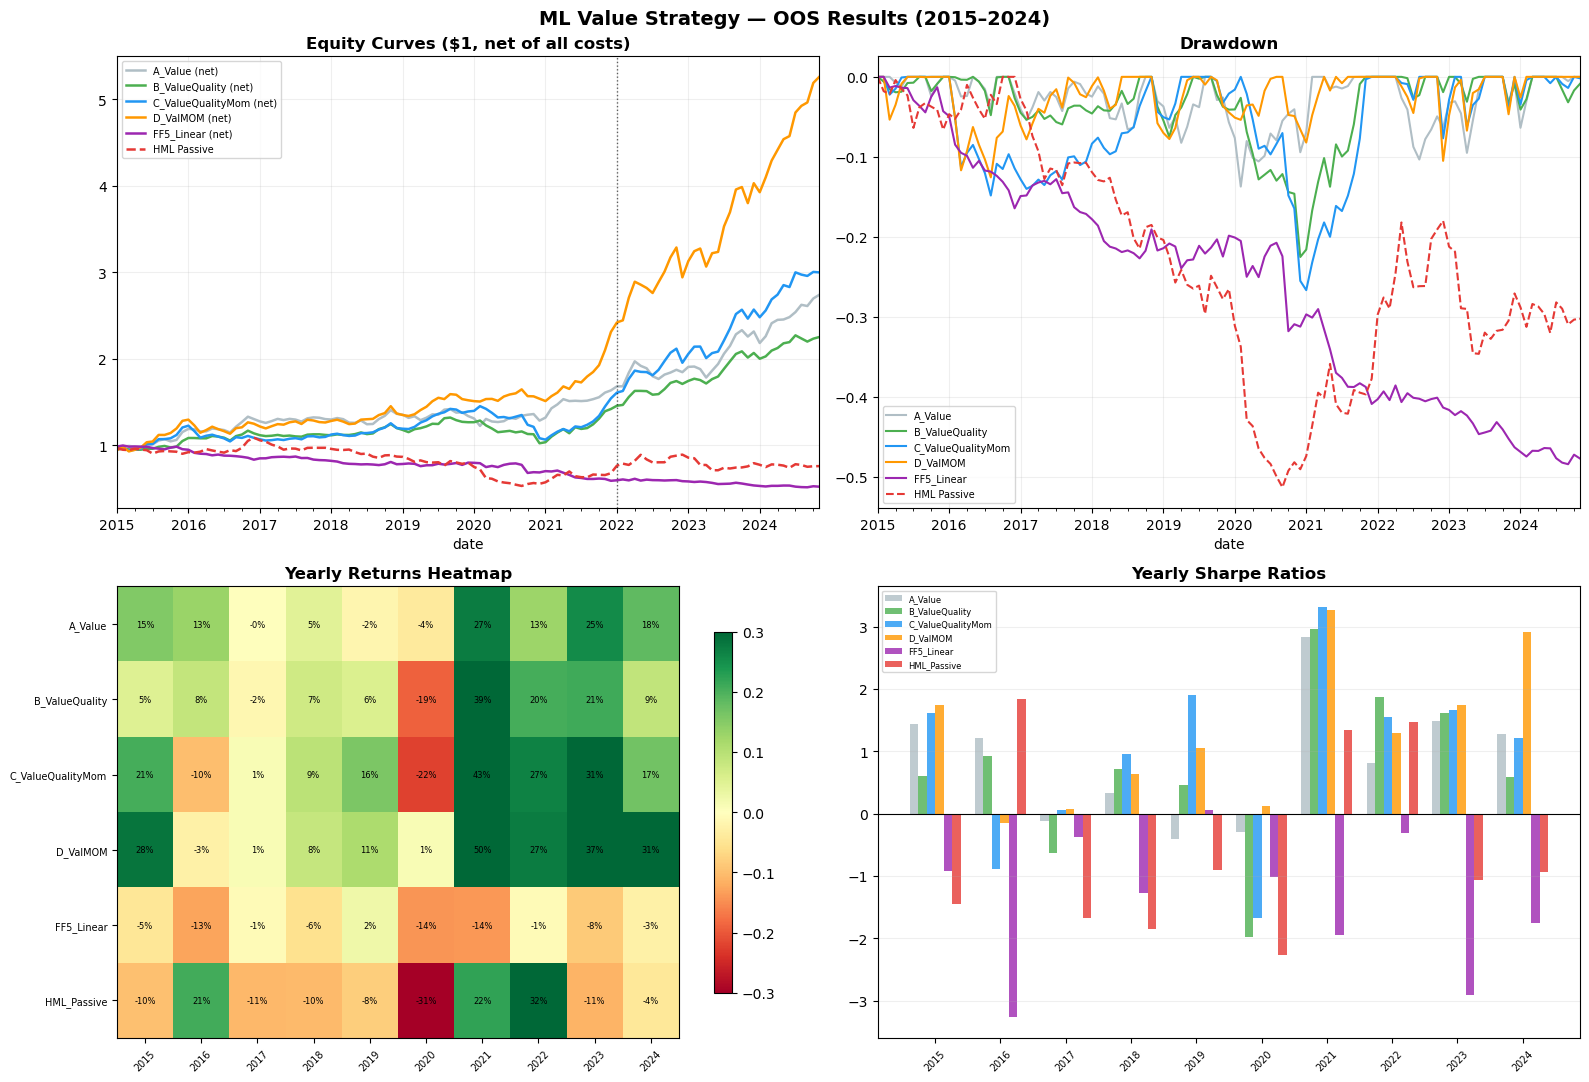

Saved: ml_value_results.png


In [17]:

# ============================================================
# STEP 23: PLOTS
# ============================================================

colors_strat = {
    'A_Value':           '#B0BEC5',
    'B_ValueQuality':    '#4CAF50',
    'C_ValueQualityMom': '#2196F3',
    'D_ValMOM':          '#FF9800',
    'FF5_Linear':        '#9C27B0',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(f'ML Value Strategy — OOS Results ({TEST_START[:4]}–2024)',
             fontsize=14, fontweight='bold')

# Equity curves
ax = axes[0,0]
for name, port in portfolios.items():
    (1 + port['ls_ret']).cumprod().plot(
        ax=ax, label=f"{name} (net)",
        color=colors_strat.get(name,'#999'), lw=1.8)
(1 + hml.reindex(portfolios['A_Value'].index).dropna()).cumprod().plot(
    ax=ax, label='HML Passive', color='#E53935', lw=1.8, ls='--')
ax.axvline(pd.Timestamp(EXT_START), color='black', lw=1, ls=':', alpha=0.6)
ax.set_title('Equity Curves ($1, net of all costs)', fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.2)

# Drawdown
ax = axes[0,1]
for name, port in portfolios.items():
    cum = (1 + port['ls_ret']).cumprod()
    ((cum - cum.cummax()) / cum.cummax()).plot(
        ax=ax, label=name, color=colors_strat.get(name,'#999'), lw=1.5)
hml_s = hml.reindex(portfolios['A_Value'].index).dropna()
cum_h = (1 + hml_s).cumprod()
((cum_h - cum_h.cummax()) / cum_h.cummax()).plot(
    ax=ax, label='HML Passive', color='#E53935', lw=1.5, ls='--')
ax.set_title('Drawdown', fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.2)

# Yearly returns heatmap
ax = axes[1,0]
plot_cols = [c for c in ['A_Value','B_ValueQuality','C_ValueQualityMom',
                          'D_ValMOM','FF5_Linear','HML_Passive']
             if c in yearly_return.columns]
yr_plot = yearly_return[plot_cols].dropna(how='all')
im = ax.imshow(yr_plot.T.values, aspect='auto', cmap='RdYlGn', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(len(yr_plot.index)))
ax.set_xticklabels(yr_plot.index, rotation=45, fontsize=7)
ax.set_yticks(range(len(plot_cols))); ax.set_yticklabels(plot_cols, fontsize=7)
for i in range(len(plot_cols)):
    for j in range(len(yr_plot.index)):
        val = yr_plot.iloc[j,i]
        if pd.notna(val):
            ax.text(j, i, f"{val:.0%}", ha='center', va='center',
                    fontsize=6, color='black')
ax.set_title('Yearly Returns Heatmap', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# Yearly Sharpe bars
ax = axes[1,1]
x = np.arange(len(yearly_sharpe.index))
w = 0.13
for i, col in enumerate(plot_cols):
    if col in yearly_sharpe.columns:
        vals = yearly_sharpe[col].reindex(yearly_sharpe.index).fillna(0)
        ax.bar(x + i*w, vals, w, label=col,
               color=colors_strat.get(col,'#E53935'), alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x + w*2.5)
ax.set_xticklabels(yearly_sharpe.index, rotation=45, fontsize=7)
ax.set_title('Yearly Sharpe Ratios', fontweight='bold')
ax.legend(fontsize=6); ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('ml_value_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ml_value_results.png")


In [18]:

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*70)
print("ALL DONE")
print("="*70)
print("Output files:")
for f in ['master_allocation.csv',
          'insample_allocation.csv',
          'full_history_allocation.csv',
          'yearly_returns.csv',
          'yearly_sharpe.csv',
          'ml_value_results.png']:
    print(f"  {f}")
print("\nCost model applied:")
print(f"  TC one-way:       {TC_ONEWAY*10000:.0f} bps")
print(f"  Stock borrow:     {BORROW_COST_ANNUAL*100:.0f} bps/yr")
print(f"  Rebate haircut:   {REBATE_HAIRCUT*100:.0f} bps/yr")
print(f"  Capital factor:   {CAPITAL_EFFICIENCY:.3f}  (Reg T 50% margin → $1.50 capital per $1 L/S)")


ALL DONE
Output files:
  master_allocation.csv
  insample_allocation.csv
  full_history_allocation.csv
  yearly_returns.csv
  yearly_sharpe.csv
  ml_value_results.png

Cost model applied:
  TC one-way:       50 bps
  Stock borrow:     2 bps/yr
  Rebate haircut:   0 bps/yr
  Capital factor:   0.667  (Reg T 50% margin → $1.50 capital per $1 L/S)
